# Conversion Rate Analysis — Modernized Workflow (2026)

A refreshed version of **“Conversion Rate — Yusen Miao”**, preserving the original business goal while replacing outdated or leakage-prone practices.

## Business questions

1. Which users are most likely to convert?
2. Which factors are associated with conversion?
3. How can the model support targeting without overstating causality?

## What is improved

- Portable data loading instead of a hard-coded Windows path.
- Explicit schema and data-quality validation.
- Stratified train/test split **before** any model fitting or resampling.
- All observations retained; no destructive undersampling.
- Leakage-safe `Pipeline` + `ColumnTransformer` preprocessing.
- A baseline, interpretable logistic model, and nonlinear gradient-boosting model.
- Imbalance-aware evaluation: average precision, ROC AUC, precision, recall, F1, calibration, and lift.
- Cross-validated decision-threshold tuning with `TunedThresholdClassifierCV`.
- An untouched final test set.
- Permutation importance on original business features.
- Separate **acquisition-time** and **in-session** feature sets.

> **Important:** `total_pages_visited` is generally known only after a session has begun. It may be useful for in-session intervention, but it should not be used in an acquisition-time model.

## 0. Environment

Recommended minimum versions:

- Python 3.10+
- pandas 2.2+
- scikit-learn 1.5+ (`TunedThresholdClassifierCV` was added in 1.5)
- matplotlib 3.8+
- seaborn 0.13+

Uncomment the installation line only when your environment needs it.

In [ ]:
# %pip install -U "pandas>=2.2" "scikit-learn>=1.5" "matplotlib>=3.8" "seaborn>=0.13" joblib

In [1]:
from __future__ import annotations

from pathlib import Path
import platform
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    StratifiedKFold,
    TunedThresholdClassifierCV,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(context="notebook", style="whitegrid")

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "scikit_learn": sklearn.__version__,
})

{'python': '3.12.5', 'pandas': '2.2.2', 'numpy': '2.1.0', 'scikit_learn': '1.8.0'}


## 1. Configuration and data loading

The source repository does not contain `conversion_data.csv`. Put the CSV beside this notebook, in a `data/` directory, or update `DATA_PATH`.

In [2]:
RANDOM_STATE = 42
TARGET = "converted"
DATA_PATH = Path("conversion_data.csv")
DATA_URL: str | None = None  # Optional: set to a trusted direct CSV URL.
TEST_SIZE = 0.20
CV_SPLITS = 3
THRESHOLD_SCORING = "f1"  # Change to another binary scorer when business costs differ.
DROP_EXACT_DUPLICATES = False  # Repeated-looking sessions may be legitimate.

EXPECTED_COLUMNS = {
    "country",
    "age",
    "new_user",
    "source",
    "total_pages_visited",
    TARGET,
}

FEATURE_SETS = {
    "acquisition": ["country", "age", "new_user", "source"],
    "in_session": ["country", "age", "new_user", "source", "total_pages_visited"],
}


def load_conversion_data(
    data_path: Path = DATA_PATH,
    data_url: str | None = DATA_URL,
) -> tuple[pd.DataFrame, str]:
    candidates = [
        data_path,
        Path("data") / data_path.name,
        Path("../data") / data_path.name,
        Path("../") / data_path.name,
    ]

    for candidate in candidates:
        if candidate.exists():
            return pd.read_csv(candidate), str(candidate.resolve())

    if data_url:
        return pd.read_csv(data_url), data_url

    searched = "\n".join(f"  - {path.resolve()}" for path in candidates)
    raise FileNotFoundError(
        "conversion_data.csv was not found. Place it beside the notebook, "
        "put it in a data/ directory, or update DATA_PATH/DATA_URL.\n"
        f"Searched:\n{searched}"
    )


raw, data_source = load_conversion_data()
print(f"Loaded {len(raw):,} rows from: {data_source}")
display(raw.head())

Loaded 316,200 rows from: C:\Users\leomi\Desktop\learning\Selflearning\MLE__\Leo_git_repos\Data-Science-Project\01_Conversion Rate\conversion_data.csv


,country,age,new_user,source,total_pages_visited,converted
0,UK,25,1,Ads,1,0
1,US,23,1,Seo,5,0
2,US,28,1,Seo,4,0
3,China,39,1,Seo,5,0
4,US,30,1,Seo,6,0


## 2. Validate and clean the data

The original notebook found two impossible ages (`111` and `123`). This version makes the rule explicit and reports every removal.

In [3]:
def validate_and_clean(raw_data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    data = raw_data.copy()
    data.columns = data.columns.str.strip().str.lower()

    missing_columns = EXPECTED_COLUMNS - set(data.columns)
    extra_columns = set(data.columns) - EXPECTED_COLUMNS
    if missing_columns:
        raise ValueError(f"Missing required columns: {sorted(missing_columns)}")
    if extra_columns:
        print(f"Extra columns retained but not modeled: {sorted(extra_columns)}")

    # Normalize types.
    for column in ["age", "new_user", "total_pages_visited", TARGET]:
        data[column] = pd.to_numeric(data[column], errors="coerce")
    for column in ["country", "source"]:
        data[column] = data[column].astype("string").str.strip()

    report_rows: list[dict[str, object]] = []

    def record(rule: str, mask: pd.Series) -> None:
        report_rows.append({"rule": rule, "rows": int(mask.sum())})

    missing_target = data[TARGET].isna()
    record("missing target", missing_target)
    data = data.loc[~missing_target].copy()

    invalid_target = ~data[TARGET].isin([0, 1])
    record("target outside {0, 1}", invalid_target)
    data = data.loc[~invalid_target].copy()

    invalid_age = data["age"].notna() & ~data["age"].between(0, 100)
    record("age outside [0, 100]", invalid_age)
    data = data.loc[~invalid_age].copy()

    invalid_pages = data["total_pages_visited"].notna() & (data["total_pages_visited"] < 0)
    record("negative total_pages_visited", invalid_pages)
    data = data.loc[~invalid_pages].copy()

    invalid_new_user = data["new_user"].notna() & ~data["new_user"].isin([0, 1])
    record("new_user outside {0, 1}", invalid_new_user)
    data = data.loc[~invalid_new_user].copy()

    duplicate_mask = data.duplicated(keep="first")
    record("exact duplicate rows detected", duplicate_mask)
    if DROP_EXACT_DUPLICATES:
        data = data.loc[~duplicate_mask].copy()

    data[TARGET] = data[TARGET].astype("int8")
    data["new_user"] = data["new_user"].astype("Int8")
    data = data.reset_index(drop=True)

    report = pd.DataFrame(report_rows)
    return data, report


data, cleaning_report = validate_and_clean(raw)
print(f"Clean shape: {data.shape}")
display(cleaning_report)
display(data.describe(include="all").T)

Clean shape: (316198, 6)


,rule,rows
0,missing target,0
1,"target outside {0, 1}",0
2,"age outside [0, 100]",2
3,negative total_pages_visited,0
4,"new_user outside {0, 1}",0
5,exact duplicate rows detected,299903


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,316198,4,US,178092,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,"316,198.0000",NaN,NaN,NaN,30.5693,8.2690,17.0000,24.0000,30.0000,36.0000,79.0000
new_user,"316,198.0000",<NA>,<NA>,<NA>,0.6855,0.4643,0.0000,0.0000,1.0000,1.0000,1.0000
source,316198,3,Seo,155039,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_pages_visited,"316,198.0000",NaN,NaN,NaN,4.8729,3.3411,1.0000,2.0000,4.0000,7.0000,29.0000
converted,"316,198.0000",NaN,NaN,NaN,0.0323,0.1767,0.0000,0.0000,0.0000,0.0000,1.0000


In [4]:
quality_summary = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_pct": data.isna().mean(),
    "unique": data.nunique(dropna=True),
}).sort_index()

display(quality_summary)
print("Target distribution:")
display(data[TARGET].value_counts().rename("rows").to_frame().assign(
    share=lambda x: x["rows"] / x["rows"].sum()
))

,dtype,missing,missing_pct,unique
age,int64,0,0.0000,58
converted,int8,0,0.0000,2
country,string,0,0.0000,4
new_user,Int8,0,0.0000,2
source,string,0,0.0000,3
total_pages_visited,int64,0,0.0000,29


Target distribution:


,rows,share
converted,,
0,306000,0.9677
1,10198,0.0323


## 3. Exploratory analysis with uncertainty

Raw group rates are descriptive, not causal. Wilson confidence intervals help distinguish signal from noise in smaller groups.

# Leo:
## Explanation: Calculates the adjusted midpoint (center) of the confidence interval.
 Notice that unlike the standard normal approximation (which centers on $p$), the Wilson interval pulls the midpoint slightly toward $0.5$ (especially for small totals) to act as a stabilizer.Math formula:$$\tilde{p} = \frac{p + \frac{z^2}{2n}}{1 + \frac{z^2}{n}}$$Example: For $p = 0.1$, $n = 100$, $z = 1.96$:
 
 Center $= \frac{0.1 + \frac{3.8416}{200}}{1.038416} = \frac{0.1 + 0.019208}{1.038416} \approx 0.1148$

## Margin of Error Calculation
Explanation: Computes the width distance from the center point to the upper/lower bounds. It combines standard binomial variance $p(1-p)$ with a correction term $z^2 / 4n$ to handle boundary extremes ($p=0$ or $p=1$).Math formula:$$\text{Margin} = \frac{z}{1 + \frac{z^2}{n}} \sqrt{\frac{p(1 - p)}{n} + \frac{z^2}{4n^2}}$$Example: Continuing with $p = 0.1$, $n = 100$, $z = 1.96$:Margin $\approx 0.0620$

## Returning Lower and Upper Bounds
Explanation: Returns a tuple containing two NumPy arrays or floats representing the lower bound (center - margin) and upper bound (center + margin) of the confidence interval.

Example Output:Lower bound $\approx 0.1148 - 0.0620 = 0.0528$ ($5.28\%$)
* Upper bound $\approx 0.1148 + 0.0620 = 0.1768$ ($17.68\%$)
* Output tuple: (array([0.0528]), array([0.1768]))

In [5]:
def wilson_interval(successes: pd.Series | np.ndarray, totals: pd.Series | np.ndarray, z: float = 1.96):
    successes = np.asarray(successes, dtype=float)
    totals = np.asarray(totals, dtype=float)
    p = np.divide(successes, totals, out=np.zeros_like(successes), where=totals > 0)
    denominator = 1 + z**2 / totals # Computes the normalizing denominator factor for the Wilson center and margin.
    center = (p + z**2 / (2 * totals)) / denominator # Explanation: Calculates the adjusted midpoint (center) 
    margin = z * np.sqrt((p * (1 - p) + z**2 / (4 * totals)) / totals) / denominator
    return center - margin, center + margin


def segment_summary(frame: pd.DataFrame, column: str) -> pd.DataFrame:
    summary = (
        frame.groupby(column, dropna=False, observed=True)[TARGET]
        .agg(users="size", conversions="sum", conversion_rate="mean")
        .reset_index()
    )
    low, high = wilson_interval(summary["conversions"], summary["users"])
    summary["ci_low_95"] = low
    summary["ci_high_95"] = high
    return summary.sort_values("conversion_rate", ascending=False)


overall_rate = data[TARGET].mean()
print(f"Overall conversion rate: {overall_rate:.2%} ({data[TARGET].sum():,}/{len(data):,})")

country_summary = segment_summary(data, "country")
source_summary = segment_summary(data, "source")
new_user_summary = segment_summary(data, "new_user")

display(country_summary)
display(source_summary)
display(new_user_summary)

Overall conversion rate: 3.23% (10,198/316,198)


,country,users,conversions,conversion_rate,ci_low_95,ci_high_95
1,Germany,13055,815,0.0624,0.0584,0.0667
2,UK,48449,2549,0.0526,0.0507,0.0546
3,US,178092,6732,0.0378,0.0369,0.0387
0,China,76602,102,0.0013,0.0011,0.0016


,source,users,conversions,conversion_rate,ci_low_95,ci_high_95
0,Ads,88739,3059,0.0345,0.0333,0.0357
2,Seo,155039,5099,0.0329,0.0320,0.0338
1,Direct,72420,2040,0.0282,0.0270,0.0294


,new_user,users,conversions,conversion_rate,ci_low_95,ci_high_95
0,0,99454,7159,0.0720,0.0704,0.0736
1,1,216744,3039,0.0140,0.0135,0.0145


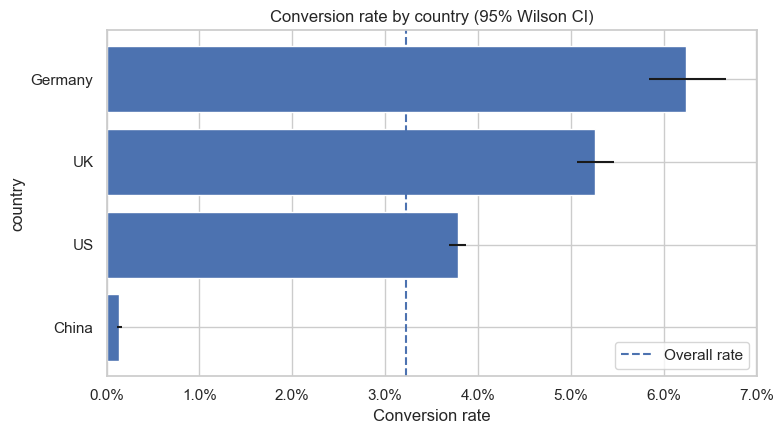

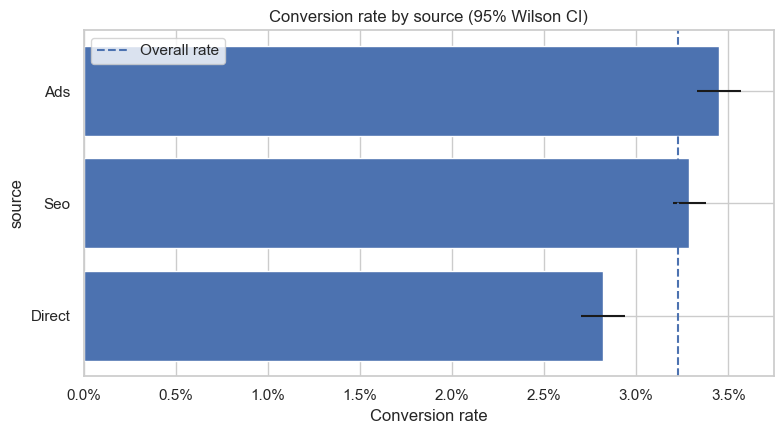

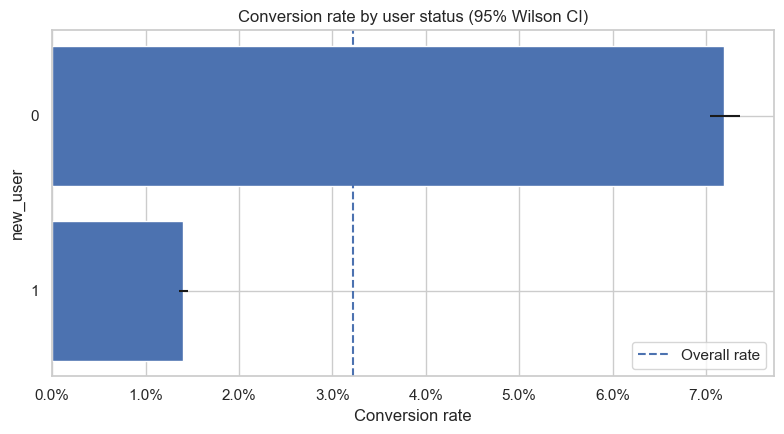

In [6]:
def plot_segment_rate(summary: pd.DataFrame, column: str, title: str) -> None:
    plot_data = summary.sort_values("conversion_rate")
    errors = np.vstack([
        plot_data["conversion_rate"] - plot_data["ci_low_95"],
        plot_data["ci_high_95"] - plot_data["conversion_rate"],
    ])
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(plot_data[column].astype(str), plot_data["conversion_rate"], xerr=errors)
    ax.axvline(overall_rate, linestyle="--", label="Overall rate")
    ax.set(title=title, xlabel="Conversion rate", ylabel=column)
    ax.xaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_segment_rate(country_summary, "country", "Conversion rate by country (95% Wilson CI)")
plot_segment_rate(source_summary, "source", "Conversion rate by source (95% Wilson CI)")
plot_segment_rate(new_user_summary, "new_user", "Conversion rate by user status (95% Wilson CI)")

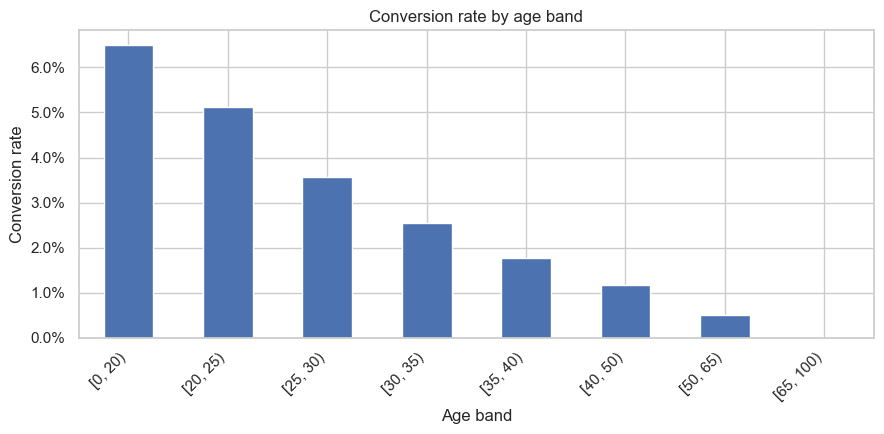

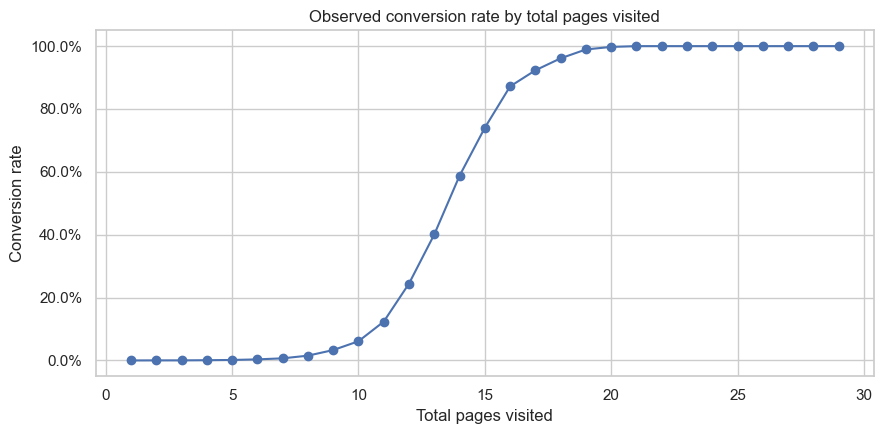

In [7]:
age_plot = data.assign(age_band=pd.cut(
    data["age"], bins=[0, 20, 25, 30, 35, 40, 50, 65, 100], right=False
))
pages_plot = data.groupby("total_pages_visited", observed=True)[TARGET].agg(users="size", conversion_rate="mean").reset_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
(
    age_plot.groupby("age_band", observed=True)[TARGET]
    .mean()
    .plot(kind="bar", ax=ax)
)
ax.set(title="Conversion rate by age band", xlabel="Age band", ylabel="Conversion rate")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pages_plot["total_pages_visited"], pages_plot["conversion_rate"], marker="o")
ax.set(
    title="Observed conversion rate by total pages visited",
    xlabel="Total pages visited",
    ylabel="Conversion rate",
)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
plt.tight_layout()
plt.show()

### Interpretation guardrails

- Country, age, source, user status, and page count are **associations** in observational data.
- `total_pages_visited` is especially vulnerable to reverse causality and timing leakage: people who are already intent on buying may naturally view more pages.
- Any recommendation should be validated with a randomized experiment or a carefully designed causal analysis.
- Age may be sensitive or regulated in some contexts. Review policy and fairness requirements before using it for targeting.

## 4. Untouched test split

The split occurs before preprocessing, model selection, or threshold tuning. Stratification preserves the rare positive-class share.

In [8]:
train_data, test_data = train_test_split(
    data,
    test_size=TEST_SIZE,
    stratify=data[TARGET],
    random_state=RANDOM_STATE,
)

train_data = train_data.reset_index(drop=True)
test_data = test_data.reset_index(drop=True)

y_train = train_data[TARGET]
y_test = test_data[TARGET]

split_check = pd.DataFrame({
    "rows": [len(train_data), len(test_data)],
    "conversion_rate": [y_train.mean(), y_test.mean()],
}, index=["train", "test"])
display(split_check)

,rows,conversion_rate
train,252958,0.0323
test,63240,0.0323


## 5. Leakage-safe preprocessing and candidate models

Categorical values are imputed and one-hot encoded inside each cross-validation fold. Numeric values are imputed and standardized. The nonlinear model can capture the sharp, non-linear relationship between engagement and conversion.

In [ ]:
NUMERIC_COLUMNS = {"age", "new_user", "total_pages_visited"}
CATEGORICAL_COLUMNS = {"country", "source"}


def make_preprocessor(features: list[str]) -> ColumnTransformer:
    numeric = [column for column in features if column in NUMERIC_COLUMNS]
    categorical = [column for column in features if column in CATEGORICAL_COLUMNS]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipe, numeric),
            ("categorical", categorical_pipe, categorical),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(features: list[str], estimator) -> Pipeline:
    return Pipeline([
        ("preprocess", make_preprocessor(features)),
        ("model", estimator),
    ])


candidate_specs = {
    "Dummy | acquisition": {
        "features": FEATURE_SETS["acquisition"],
        "estimator": DummyClassifier(strategy="prior"),
    },
    "Logistic | acquisition": {
        "features": FEATURE_SETS["acquisition"],
        "estimator": LogisticRegression(max_iter=2_000, solver="lbfgs"),
    },
    "Logistic balanced | acquisition": {
        "features": FEATURE_SETS["acquisition"],
        "estimator": LogisticRegression(
            max_iter=2_000,
            solver="lbfgs", # find the curve and how steep that is. so that it's easier to find the btter coefficients
            class_weight="balanced", # This tells logistic regression to give more importance to the minority class. scikit-learn assigns approximately larger weights to class 1 and smaller weights to class 0
        ),
    },
    "Logistic | in-session": {
        "features": FEATURE_SETS["in_session"],
        "estimator": LogisticRegression(max_iter=2_000, solver="lbfgs"),
    },
    "HistGradientBoosting | in-session": {
        "features": FEATURE_SETS["in_session"],
        "estimator": HistGradientBoostingClassifier(
            learning_rate=0.08,
            max_iter=200,
            max_leaf_nodes=15,
            min_samples_leaf=50,
            l2_regularization=1.0,
            early_stopping=True,
            random_state=RANDOM_STATE,
        ),
    },
}

for spec in candidate_specs.values():
    spec["pipeline"] = make_model_pipeline(spec["features"], spec["estimator"])

## 6. Cross-validated model comparison

**Average precision (AP)** is the primary selection metric because it focuses on positive-class ranking under strong class imbalance. ROC AUC and log loss are included for context; accuracy is intentionally not used for model selection.

In [10]:
cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "neg_log_loss": "neg_log_loss",
}

cv_rows = []
for name, spec in candidate_specs.items():
    features = spec["features"]
    scores = cross_validate(
        spec["pipeline"],
        train_data[features],
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        return_train_score=False,
    )
    cv_rows.append({
        "model": name,
        "feature_set": "in_session" if "in-session" in name else "acquisition",
        "cv_average_precision": scores["test_average_precision"].mean(),
        "cv_average_precision_sd": scores["test_average_precision"].std(ddof=1),
        "cv_roc_auc": scores["test_roc_auc"].mean(),
        "cv_log_loss": -scores["test_neg_log_loss"].mean(),
        "fit_seconds": scores["fit_time"].sum(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_average_precision", ascending=False)
display(cv_results)

eligible = cv_results.loc[~cv_results["model"].str.startswith("Dummy")]
selected_name = eligible.iloc[0]["model"]
selected_spec = candidate_specs[selected_name]
selected_features = selected_spec["features"]
selected_pipeline = selected_spec["pipeline"]

print(f"Selected model: {selected_name}")
print(f"Features: {selected_features}")

,model,feature_set,cv_average_precision,cv_average_precision_sd,cv_roc_auc,cv_log_loss,fit_seconds
3,Logistic | in-session,in_session,0.8444,0.0048,0.9863,0.0404,1.8306
4,HistGradientBoosting | in-session,in_session,0.8418,0.0052,0.9858,0.0409,11.6589
1,Logistic | acquisition,acquisition,0.1333,0.0058,0.8203,0.1195,1.3393
2,Logistic balanced | acquisition,acquisition,0.1332,0.0058,0.8203,0.5282,1.5928
0,Dummy | acquisition,acquisition,0.0323,0.0000,0.5000,0.1425,0.9604


Selected model: Logistic | in-session
Features: ['country', 'age', 'new_user', 'source', 'total_pages_visited']


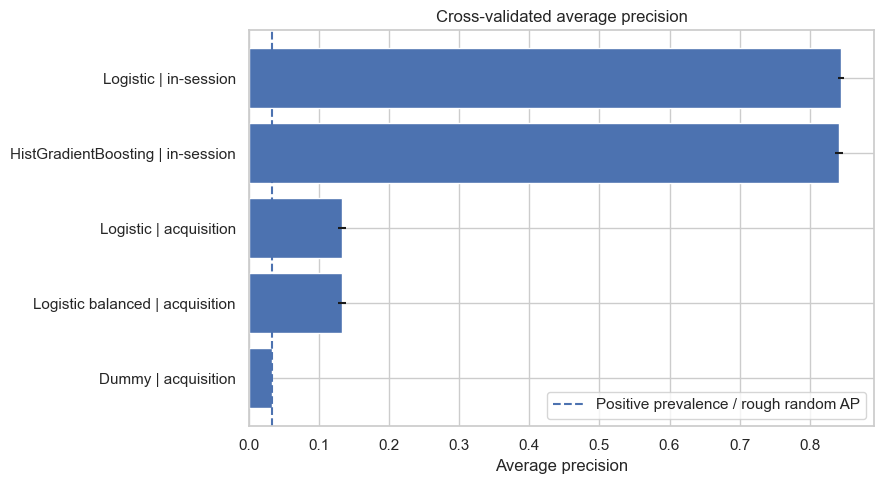

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_cv = cv_results.sort_values("cv_average_precision")
ax.barh(plot_cv["model"], plot_cv["cv_average_precision"], xerr=plot_cv["cv_average_precision_sd"])
ax.axvline(y_train.mean(), linestyle="--", label="Positive prevalence / rough random AP")
ax.set(title="Cross-validated average precision", xlabel="Average precision", ylabel="")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Cross-validated decision-threshold tuning

A default `0.50` threshold is rarely optimal for an imbalanced problem. `TunedThresholdClassifierCV` searches thresholds using only the training data and refits the estimator afterward.

`THRESHOLD_SCORING="f1"` balances precision and recall. In production, replace it with a metric or cost function that reflects campaign economics, review capacity, and the cost of false positives versus false negatives.

In [12]:
X_train_selected = train_data[selected_features]
X_test_selected = test_data[selected_features]

# Reference model using the conventional 0.50 threshold.
default_model = clone(selected_pipeline).fit(X_train_selected, y_train)
default_probability = default_model.predict_proba(X_test_selected)[:, 1]
default_prediction = (default_probability >= 0.50).astype(int)

# Modern cross-validated threshold tuning. The final test data is never used here.
threshold_model = TunedThresholdClassifierCV(
    estimator=clone(selected_pipeline),
    scoring=THRESHOLD_SCORING,
    thresholds=200,
    cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    refit=True,
    n_jobs=-1,
    store_cv_results=True,
)
threshold_model.fit(X_train_selected, y_train)

tuned_probability = threshold_model.predict_proba(X_test_selected)[:, 1]
tuned_prediction = threshold_model.predict(X_test_selected)

print(f"Best cross-validated threshold: {threshold_model.best_threshold_:.4f}")
print(f"Best CV {THRESHOLD_SCORING}: {threshold_model.best_score_:.4f}")

Best cross-validated threshold: 0.3869
Best CV f1: 0.7701


In [13]:
def evaluate_binary(y_true, probability, prediction, label: str) -> pd.Series:
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return pd.Series({
        "model": label,
        "positive_rate": np.mean(y_true),
        "roc_auc": roc_auc_score(y_true, probability),
        "average_precision": average_precision_score(y_true, probability),
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "brier_score": brier_score_loss(y_true, probability),
        "log_loss": log_loss(y_true, probability, labels=[0, 1]),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
    })


test_metrics = pd.DataFrame([
    evaluate_binary(y_test, default_probability, default_prediction, "Default threshold = 0.50"),
    evaluate_binary(y_test, tuned_probability, tuned_prediction, f"Tuned threshold = {threshold_model.best_threshold_:.3f}"),
]).set_index("model")

display(test_metrics.T)
print("Classification report — tuned threshold")
print(classification_report(y_test, tuned_prediction, digits=4, zero_division=0))

model,Default threshold = 0.50,Tuned threshold = 0.387
positive_rate,0.0323,0.0323
roc_auc,0.9849,0.9849
average_precision,0.8387,0.8387
precision,0.8517,0.7980
recall,0.6926,0.7397
f1,0.7640,0.7677
balanced_accuracy,0.8443,0.8667
brier_score,0.0110,0.0110
log_loss,0.0415,0.0415
true_positives,"1,413.0000","1,509.0000"


Classification report — tuned threshold
              precision    recall  f1-score   support

           0     0.9913    0.9938    0.9925     61200
           1     0.7980    0.7397    0.7677      2040

    accuracy                         0.9856     63240
   macro avg     0.8947    0.8667    0.8801     63240
weighted avg     0.9851    0.9856    0.9853     63240



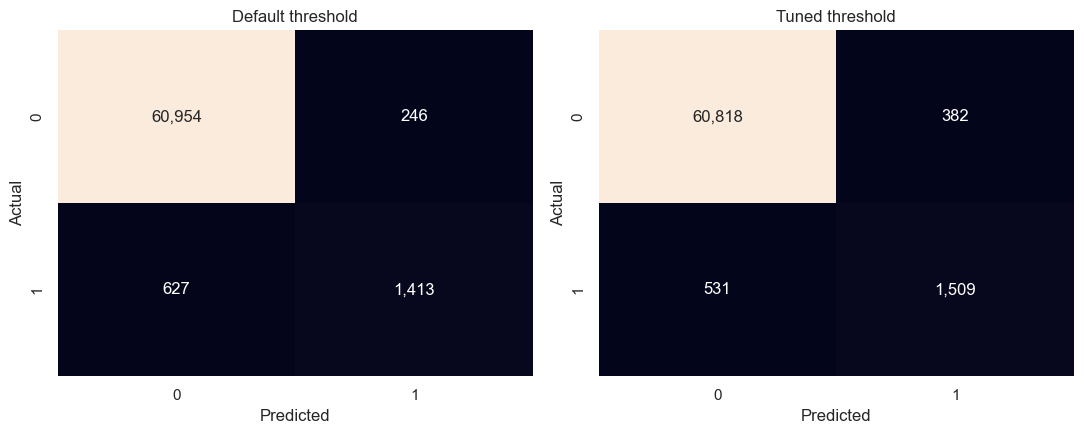

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, prediction, title in [
    (axes[0], default_prediction, "Default threshold"),
    (axes[1], tuned_prediction, "Tuned threshold"),
]:
    cm = confusion_matrix(y_test, prediction, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt=",d", cbar=False, ax=ax)
    ax.set(title=title, xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
plt.show()

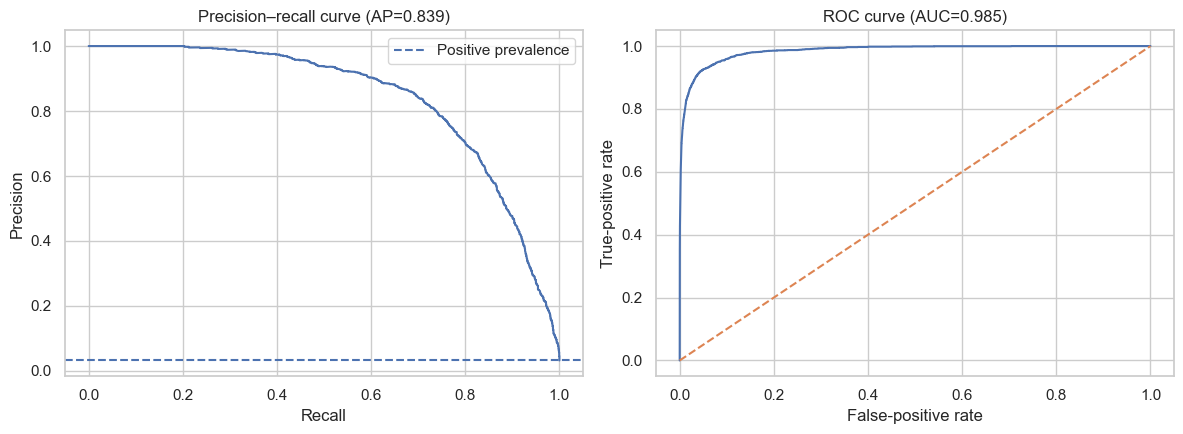

In [15]:
precision, recall, _ = precision_recall_curve(y_test, tuned_probability)
fpr, tpr, _ = roc_curve(y_test, tuned_probability)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(recall, precision)
axes[0].axhline(y_test.mean(), linestyle="--", label="Positive prevalence")
axes[0].set(
    title=f"Precision–recall curve (AP={average_precision_score(y_test, tuned_probability):.3f})",
    xlabel="Recall",
    ylabel="Precision",
)
axes[0].legend()

axes[1].plot(fpr, tpr)
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set(
    title=f"ROC curve (AUC={roc_auc_score(y_test, tuned_probability):.3f})",
    xlabel="False-positive rate",
    ylabel="True-positive rate",
)
plt.tight_layout()
plt.show()

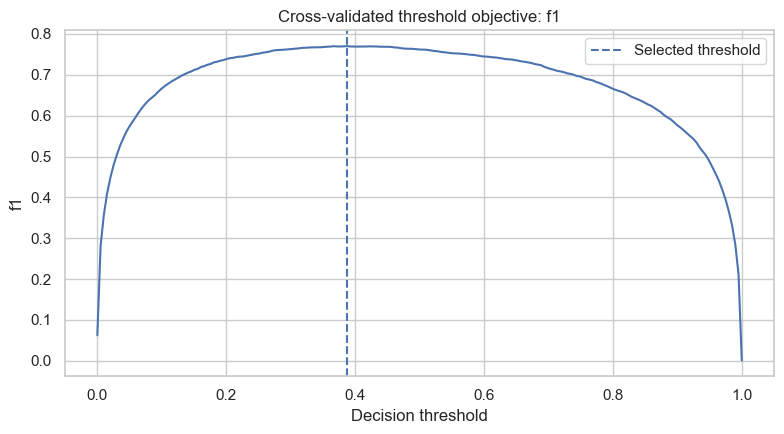

In [16]:
threshold_curve = pd.DataFrame(threshold_model.cv_results_)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(threshold_curve["thresholds"], threshold_curve["scores"])
ax.axvline(threshold_model.best_threshold_, linestyle="--", label="Selected threshold")
ax.set(
    title=f"Cross-validated threshold objective: {THRESHOLD_SCORING}",
    xlabel="Decision threshold",
    ylabel=THRESHOLD_SCORING,
)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Model interpretation on original features

Permutation importance measures the loss in test-set average precision after shuffling each original feature. It works with the entire preprocessing pipeline and is easier to compare across numeric and categorical inputs than raw coefficient magnitudes.

It is still **predictive importance**, not causal effect.

,feature,importance_mean,importance_sd
4,total_pages_visited,0.7849,0.0009
0,country,0.0725,0.0013
2,new_user,0.0534,0.0034
1,age,0.0229,0.0014
3,source,0.0004,0.0001


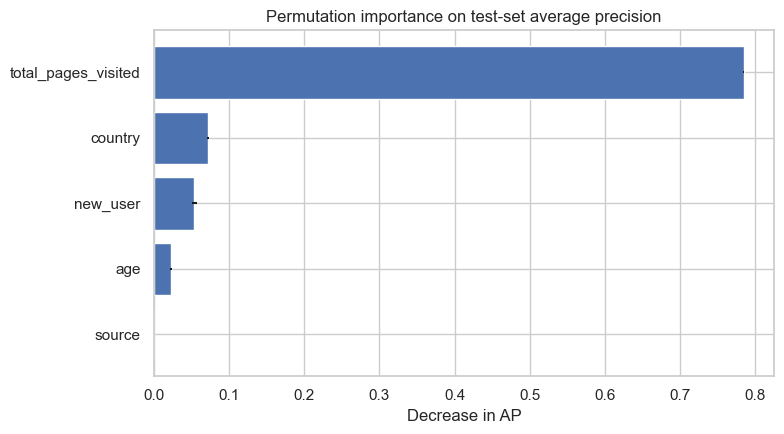

In [17]:
perm = permutation_importance(
    threshold_model,
    X_test_selected,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = (
    pd.DataFrame({
        "feature": selected_features,
        "importance_mean": perm.importances_mean,
        "importance_sd": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)
display(importance)

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_importance = importance.sort_values("importance_mean")
ax.barh(
    plot_importance["feature"],
    plot_importance["importance_mean"],
    xerr=plot_importance["importance_sd"],
)
ax.set(title="Permutation importance on test-set average precision", xlabel="Decrease in AP", ylabel="")
plt.tight_layout()
plt.show()

In [18]:
# Optional: inspect standardized logistic coefficients when the selected estimator is logistic.
fitted_pipeline = threshold_model.estimator_
fitted_estimator = fitted_pipeline.named_steps["model"]

if isinstance(fitted_estimator, LogisticRegression):
    transformed_names = fitted_pipeline.named_steps["preprocess"].get_feature_names_out()
    coefficient_table = (
        pd.DataFrame({
            "feature": transformed_names,
            "coefficient": fitted_estimator.coef_.ravel(),
            "odds_ratio": np.exp(fitted_estimator.coef_.ravel()),
        })
        .sort_values("coefficient", key=np.abs, ascending=False)
    )
    display(coefficient_table)
else:
    print("Selected estimator is nonlinear; use permutation importance above.")

,feature,coefficient,odds_ratio
3,country_China,-3.8171,0.0220
2,total_pages_visited,2.5457,12.7517
8,source_Direct,-1.6805,0.1863
9,source_Seo,-1.5353,0.2154
7,source_Ads,-1.5111,0.2207
1,new_user,-0.8152,0.4425
0,age,-0.6195,0.5382
6,country_US,-0.5792,0.5603
5,country_UK,-0.2145,0.8069
4,country_Germany,-0.1161,0.8904


## 9. Lift and conversion capture

A lift table is often more actionable than a single classification threshold. It shows how many converters are captured when users are ranked by model score.

,score_decile,users,conversions,conversion_rate,average_score,lift_vs_overall,share_of_all_conversions,cumulative_conversion_capture
0,1,6324,1921,0.3038,0.3085,9.4167,0.9417,0.9417
1,2,6324,82,0.0130,0.0104,0.4020,0.0402,0.9819
2,3,6324,17,0.0027,0.0028,0.0833,0.0083,0.9902
3,4,6324,14,0.0022,0.0011,0.0686,0.0069,0.9971
4,5,6324,3,0.0005,0.0005,0.0147,0.0015,0.9985
5,6,6324,2,0.0003,0.0003,0.0098,0.0010,0.9995
6,7,6324,0,0.0000,0.0001,0.0000,0.0000,0.9995
7,8,6324,1,0.0002,0.0001,0.0049,0.0005,1.0000
8,9,6324,0,0.0000,0.0000,0.0000,0.0000,1.0000
9,10,6324,0,0.0000,0.0000,0.0000,0.0000,1.0000


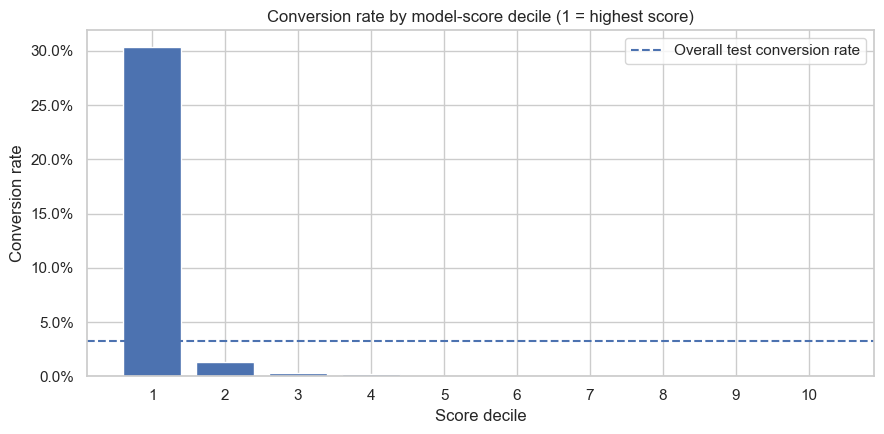

In [19]:
scored_test = test_data.copy()
scored_test["predicted_probability"] = tuned_probability
scored_test["predicted_label"] = tuned_prediction
scored_test = scored_test.sort_values("predicted_probability", ascending=False).reset_index(drop=True)

n_bins = min(10, len(scored_test))
scored_test["score_decile"] = pd.qcut(
    np.arange(len(scored_test)),
    q=n_bins,
    labels=np.arange(1, n_bins + 1),
)

lift_table = (
    scored_test.groupby("score_decile", observed=True)
    .agg(
        users=(TARGET, "size"),
        conversions=(TARGET, "sum"),
        conversion_rate=(TARGET, "mean"),
        average_score=("predicted_probability", "mean"),
    )
    .reset_index()
    .sort_values("score_decile")
)
lift_table["lift_vs_overall"] = lift_table["conversion_rate"] / y_test.mean()
lift_table["share_of_all_conversions"] = lift_table["conversions"] / lift_table["conversions"].sum()
lift_table["cumulative_conversion_capture"] = lift_table["share_of_all_conversions"].cumsum()

display(lift_table)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(lift_table["score_decile"].astype(str), lift_table["conversion_rate"])
ax.axhline(y_test.mean(), linestyle="--", label="Overall test conversion rate")
ax.set(
    title="Conversion rate by model-score decile (1 = highest score)",
    xlabel="Score decile",
    ylabel="Conversion rate",
)
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.1%}")
ax.legend()
plt.tight_layout()
plt.show()

## 10. Business conclusions and next steps

Use the executed tables and plots above to quantify each point.

1. **Treat China as a diagnosis problem, not a conclusion.** A low observed rate can reflect localization, payment methods, device mix, traffic quality, trust, or measurement. Break the funnel into steps and run localized experiments before increasing or decreasing spend.
2. **Retain and re-engage existing users.** The original data usually shows a large gap between returning and new users. Test onboarding, lifecycle messaging, saved-cart reminders, and loyalty offers with randomized holdouts.
3. **Use page count only at the right decision time.** The in-session model may rank users very well because page count captures intent. It cannot be used for acquisition bidding before those pages have been viewed, and adding pages is not itself proven to cause conversion.
4. **Operate from lift/capacity, not accuracy.** Select the top score deciles that match the outreach budget, then monitor precision, incremental conversion, cost per incremental conversion, and customer experience.
5. **Validate recommendations experimentally.** Predictive importance does not establish causality. A/B tests should determine whether reminders, promotions, localization, or acquisition changes create incremental conversions.
6. **Monitor drift and fairness.** Track feature distributions, conversion prevalence, calibration, AP, recall, and segment performance over time. Review whether age is appropriate to use; compare against a model that excludes it when policy or fairness concerns apply.

## 11. Save reusable artifacts

The fitted object includes preprocessing, the selected model, and the tuned threshold. Save it only after reviewing test performance and business requirements.

In [ ]:
MODEL_PATH = Path("conversion_threshold_model.joblib")
PREDICTIONS_PATH = Path("conversion_scored_test.csv")

joblib.dump(
    {
        "model": threshold_model,
        "selected_model_name": selected_name,
        "features": selected_features,
        "target": TARGET,
        "best_threshold": threshold_model.best_threshold_,
        "data_source": data_source,
        "sklearn_version": sklearn.__version__,
    },
    MODEL_PATH,
)
scored_test.to_csv(PREDICTIONS_PATH, index=False)

print(f"Saved model: {MODEL_PATH.resolve()}")
print(f"Saved scored test data: {PREDICTIONS_PATH.resolve()}")

### Production checklist

- Confirm that every feature is available at prediction time.
- Freeze category handling and schema validation.
- Choose a threshold from business costs or capacity, not F1 alone.
- Calibrate probabilities if they are used as literal conversion probabilities or expected-value inputs.
- Add model/data versioning, drift monitoring, and retraining criteria.
- Run a randomized experiment to measure incremental business impact.